# Importazioni

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Aggiunta path per i moduli
qml_code_dir = Path.cwd().parent
sys.path.append(str(qml_code_dir))

from sklearn.datasets import load_breast_cancer, make_circles

from moduli.preprocessing_dataset.preprocessing_dataset import preprocessa_dataset
from moduli.qsvm.screening import esegui_screening_e_pipeline
from moduli.kernel import kernel_amplitude, kernel_angle, kernel_basis, kernel_IQP


# Configurazione

In [2]:
# Numero di campioni da estrarre dal dataset totale.
numero_campioni = 200

# Rapporti con cui dividere i campioni
frazione_dati_per_train = 0.70
frazione_dati_per_val = 0.15
frazione_dati_per_test = 0.15

# Numero di features (alzato a 10 per testare appieno l'espressività e il mapping ad alta dimensionalità dell'IQP)
numero_features = 2


# Creazione o importazione dei dataset

In [3]:
# Breast Cancer
X_dataset_breast_cancer = load_breast_cancer().data
y_dataset_breast_cancer = load_breast_cancer().target
dataset_breast_cancer = (X_dataset_breast_cancer, y_dataset_breast_cancer)

# Make Circles
X_make_circles, y_make_circles = make_circles(n_samples = 5000, noise = 0.1, factor = 0.3, random_state = 1)
dataset_make_circles = (X_make_circles, y_make_circles)


# Preprocessing

In [4]:
dataset_scelto = dataset_make_circles

In [5]:
set_preparato = preprocessa_dataset(
    dataset_scelto = dataset_scelto,
    numero_campioni = numero_campioni,
    frazione_dati_per_train = frazione_dati_per_train,
    frazione_dati_per_val = frazione_dati_per_val,
    frazione_dati_per_test = frazione_dati_per_test,
    numero_features = numero_features
)



PREPROCESSING DATASET

Il numero di campioni da estrarre desiderato è valido.
I rapporti scelti sono validi.
Il numero di features richiesto, 2, è uguale alla quantità totale di features presenti nel dataset.
PCA eseguita con successo. Informazione conservata: 100.00%
Preprocessing del dataset completato.



# Screening Geometrico e Addestramento QSVM
In questa sezione filtriamo le matrici di Gram quantistiche calcolando il KTA e la Geometric Difference contro una baseline RBF. Solo i kernel che superano la soglia minima di allineamento verranno passati all'infrastruttura originale della QSVM per ottimizzare $C$.

In [6]:
griglia_classica = {
    'C': [0.1, 1.0, 10.0, 100.0]
}


## IQP Encoding

=== FASE 1: Calcolo Baseline Classica ===
Ricerca del gamma ottimale per RBF Classico tramite KTA...
Miglior gamma selezionato: 0.7848 (KTA: 0.7907)

=== FASE 2: Screening Geometrico degli Spazi di Hilbert ===

Valutazione configurazione: 1 ripetizioni, pattern 'None'
  > KTA: 0.5884 | Geometric Difference: 2777.2858 | Approvato: True
  > Configurazione valida. Inizializzazione QSVM...
QUANTUM SUPPORT VECTOR MACHINE PER IQP ENCODING

Destinazione output: risultati_run/20260630/20260630_173521/iqp_encoding_20260630_173521


Addestramento dei modelli e validazione sugli iperparametri: 100%|███████████████████████████| 4/4


Miglior iperparametro quantistico per numero_ripetizioni: 1
Miglior iperparametro quantistico per pattern: None
Miglior iperparametro classico per C: 1.0
F1-Score (Macro) del miglior modello sul validation set: 100.00%


DIAGNOSI FINALE SUL TEST SET:

╒═══════════════╤═════════════╤══════════╤════════════╤═══════════════════════════════╕
│               │  Precision  │  Recall  │  F1-Score  │  Campioni realmente presenti  │
╞═══════════════╪═════════════╪══════════╪════════════╪═══════════════════════════════╡
│   Classe 0    │   100.00%   │ 100.00%  │  100.00%   │              15               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│   Classe 1    │   100.00%   │ 100.00%  │  100.00%   │              15               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│ Medie (Macro) │   100.00%   │ 100.00%  │  100.00%   │              30               │
╘═══════════════╧═════════════╧══════════╧══

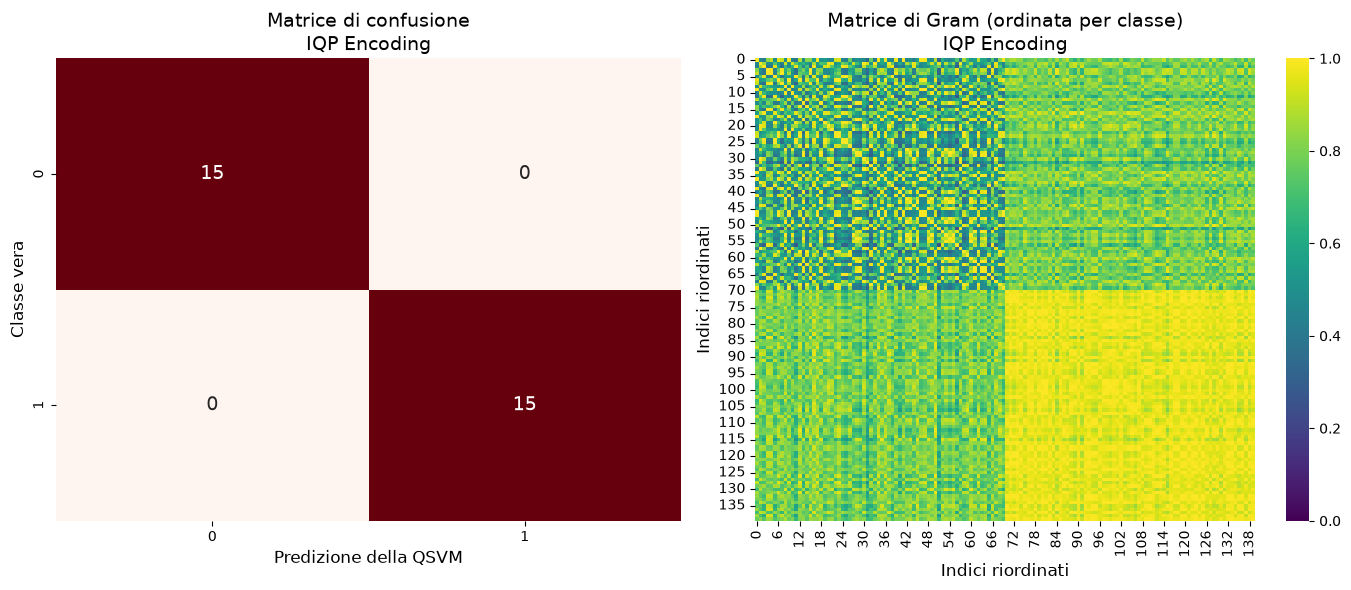


Valutazione configurazione: 1 ripetizioni, pattern 'ring'


WireError: Wire with label r not found in Wires([0, 1]).

In [7]:
griglia_quantistica_iqp = {
    'numero_ripetizioni': [1, 2, 3],
    'pattern': [None, 'ring', 'all-to-all']
}

df_analisi_iqp = esegui_screening_e_pipeline(
    set_preparato=set_preparato,
    numero_features=numero_features,
    modulo_encoding_quantistico=kernel_IQP,
    griglia_quantistica=griglia_quantistica_iqp,
    iperparametri_classici=griglia_classica,
    soglia_kta=0.05 
)

display(df_analisi_iqp)


## Angle Encoding

In [ ]:
griglia_quantistica_angle = {
    # Angle encoding di norma non richiede ripetizioni o pattern complessi,
    # ma passiamo valori fittizi per mantenere intatta la firma dell'oracolo.
    'numero_ripetizioni': [1],
    'pattern': [None]
}

df_analisi_angle = esegui_screening_e_pipeline(
    set_preparato=set_preparato,
    numero_features=numero_features,
    modulo_encoding_quantistico=kernel_angle,
    griglia_quantistica=griglia_quantistica_angle,
    iperparametri_classici=griglia_classica,
    soglia_kta=0.05 
)

display(df_analisi_angle)


## Amplitude Encoding

In [ ]:
griglia_quantistica_amplitude = {
    'numero_ripetizioni': [1],
    'pattern': [None]
}

df_analisi_amplitude = esegui_screening_e_pipeline(
    set_preparato=set_preparato,
    numero_features=numero_features,
    modulo_encoding_quantistico=kernel_amplitude,
    griglia_quantistica=griglia_quantistica_amplitude,
    iperparametri_classici=griglia_classica,
    soglia_kta=0.05 
)

display(df_analisi_amplitude)
